# Market maker et bid-ask spread — simuler le risque d'inventaire avec Python


**Prérequis :** la vidéo précédente sur rendement et volatilité (on réutilise directement $\sigma$).

**Vidéos qui s'appuieront sur celle-ci plus tard :** delta-hedging, Greeks, gestion de portefeuille d'options.

---

**Sources principales :**
- Avellaneda, M. & Stoikov, S. (2008), *High-frequency trading in a limit order book*, Quantitative Finance
- J. Hull, *Options, Futures and Other Derivatives*, 8e éd. (mécanique du market maker)
- CFA Institute, *Fixed Income Analysis* (déterminants réels du bid-ask spread)


## 1. Question

**Problème central :**

> Un market maker qui cote un bid et un ask autour du prix "juste" gagne le spread à chaque
> aller-retour. Alors pourquoi peut-il perdre bien plus que ce spread si le marché part dans un
> sens ? Et comment ajuste-t-il ses prix pour se protéger ?

**Pourquoi ça compte :** fournir de la liquidité n'est pas un métier sans risque — le vrai risque
n'est pas le spread lui-même, c'est l'inventaire qui s'accumule quand les ordres arrivent
déséquilibrés dans un sens.


## 2. Intuition

Un market maker affiche en permanence un prix d'achat (bid) et un prix de vente (ask), légèrement
en dessous et au-dessus du prix "juste" du marché. Si les ordres arrivent équilibrés — autant
d'acheteurs que de vendeurs — il empoche le spread à chaque aller-retour, sans risque directionnel.

Le problème, c'est que les ordres n'arrivent jamais parfaitement équilibrés. Si le marché est
haussier, plus de gens achètent au market maker qu'ils ne lui vendent — son inventaire devient
négatif (il a vendu plus qu'il n'a acheté), et si le prix continue de monter, il doit racheter plus
cher ce qu'il a vendu trop tôt.

L'idée du modèle qu'on va coder : au lieu de coter symétriquement autour du prix du marché, le
market maker décale ses prix en fonction de son inventaire actuel. S'il est déjà vendeur net, il
rend son prix d'achat plus attractif (pour rééquilibrer) et son prix de vente moins attractif — il
"paie" pour revenir à un inventaire neutre, plutôt que de laisser le risque s'accumuler.


## 3. Hypothèses

1. **Le prix milieu suit une marche aléatoire sans dérive** — pas de tendance anticipée, seulement
   de la volatilité $\sigma$.
2. **Les arrivées d'ordres suivent un processus de Poisson** dont l'intensité décroît de façon
   exponentielle avec la distance entre la cotation et le prix milieu — plus on cote loin du
   marché, moins on a de chance d'être exécuté.
3. **Le market maker a une aversion au risque constante** $\gamma$, et cherche à gérer son
   inventaire plutôt qu'à parier sur la direction du marché.
4. **Pas de sélection adverse modélisée** — on ne distingue pas les ordres "informés" (qui savent
   quelque chose) des ordres "bruit" ; le modèle traite tous les flux de la même façon.


## 4. Notation

| Symbole | Signification |
|---|---|
| $s_t$ | prix milieu (mid-price) à l'instant $t$ |
| $q_t$ | inventaire du market maker (positif = long, négatif = short) |
| $\gamma$ | aversion au risque du market maker |
| $\sigma$ | volatilité du prix milieu |
| $T-t$ | temps restant avant la fin de la session |
| $\kappa$ | sensibilité de l'intensité des arrivées d'ordres à la distance de cotation |
| $r_t$ | prix de réservation (le prix "ajusté" à l'inventaire) |


## 5. Mathématiques

**5.1 — Stratégie naïve (référence).** Un market maker sans gestion d'inventaire cote simplement
symétriquement autour du prix milieu :

$$\text{bid} = s_t - \delta \qquad \text{ask} = s_t + \delta$$

**5.2 — Le prix de réservation (Avellaneda-Stoikov).** Le market maker qui gère son inventaire ne
cote plus autour de $s_t$, mais autour d'un prix de réservation décalé :

$$r_t = s_t - q_t\,\gamma\,\sigma^2\,(T-t)$$

Si $q_t=0$ (inventaire neutre), $r_t=s_t$ — pas de décalage. Si $q_t>0$ (déjà long), $r_t<s_t$ :
le market maker baisse son prix pour inciter les acheteurs face à lui (vendre) et rééquilibrer.

**5.3 — Le spread optimal autour de ce prix.**

$$\delta^* = \frac{1}{\gamma}\ln\left(1+\frac{\gamma}{\kappa}\right) + \frac{1}{2}\gamma\sigma^2(T-t)$$

$$\text{bid} = r_t - \delta^* \qquad \text{ask} = r_t + \delta^*$$

**Résultat clé à vérifier avant de coder :** à $q_t=0$, cette stratégie doit se comporter comme la
stratégie naïve (même prix de référence). Et plus $\gamma$ est élevé (aversion au risque forte),
plus le décalage lié à l'inventaire doit être important.


In [2]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
rng = np.random.default_rng(7)


## 6. Implémentation

*Notebook présenté, pas codé en direct : toutes les cellules sont déjà exécutées.*


In [3]:
# Deux fonctions directement traduites des equations 5.2 et 5.3,
# le prix de reservation et le demi-spread optimal

def prix_reservation(s, q, gamma, sigma, T, t):
    return s - q*gamma*sigma**2*(T-t)

def demi_spread_optimal(gamma, kappa, sigma, T, t):
    return (1/gamma)*np.log(1+gamma/kappa) + 0.5*gamma*sigma**2*(T-t)


In [4]:
# Trois verifications avant d'aller plus loin. D'abord : a inventaire nul,
# le prix de reservation doit etre exactement le prix du marche.
# Sanity check 1

s0, gamma, sigma, T, t = 100.0, 0.1, 2.0, 1.0, 0.3
r_q0 = prix_reservation(s0, 0, gamma, sigma, T, t)
print(f"Prix de reservation a inventaire nul : {r_q0}  (prix du marche : {s0})  "
      f"-> {'coherent' if np.isclose(r_q0, s0) else 'ERREUR'}")


Prix de reservation a inventaire nul : 100.0  (prix du marche : 100.0)  -> coherent


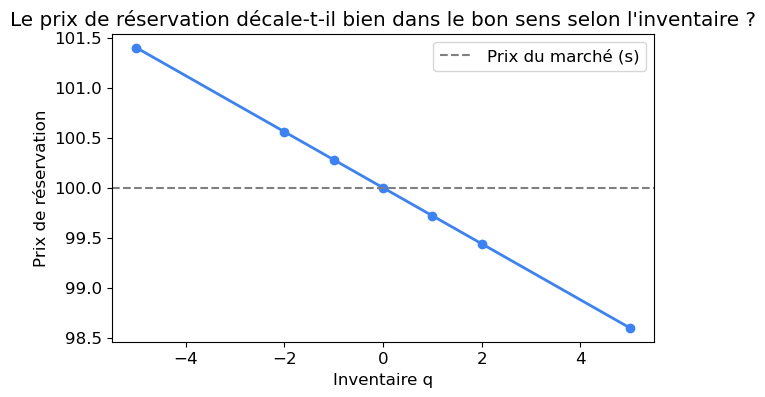

In [5]:
# Deuxieme verification : le prix de reservation doit baisser strictement
# quand l'inventaire augmente, plus on est acheteur net, plus
# on doit inciter a vendre.
# monotonie en fonction de l'inventaire

qs = np.array([-5, -2, -1, 0, 1, 2, 5])
rs = prix_reservation(s0, qs, gamma, sigma, T, t)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(qs, rs, marker="o", linewidth=2, color="#3b82f6")
ax.axhline(s0, color="grey", linestyle="--", label="Prix du marché (s)")
ax.set_title("Le prix de réservation décale-t-il bien dans le bon sens selon l'inventaire ?")
ax.set_xlabel("Inventaire q")
ax.set_ylabel("Prix de réservation")
ax.legend()
plt.show()


In [6]:
# Troisieme verification, un cas limite : si l'aversion au risque tend vers zero,
# le spread total doit se stabiliser a une valeur finie, pas s'annuler.
# convergence du spread total

kappa = 1.5
gammas_test = np.array([1.0, 0.1, 0.01, 0.001])
spreads_totaux = gammas_test*sigma**2*(T-t) + (2/gammas_test)*np.log(1+gammas_test/kappa)

for g, sp in zip(gammas_test, spreads_totaux):
    print(f"gamma={g:<8} -> spread total = {sp:.5f}   (limite theorique 2/kappa = {2/kappa:.5f})")


gamma=1.0      -> spread total = 3.82165   (limite theorique 2/kappa = 1.33333)
gamma=0.1      -> spread total = 1.57077   (limite theorique 2/kappa = 1.33333)
gamma=0.01     -> spread total = 1.35691   (limite theorique 2/kappa = 1.33333)
gamma=0.001    -> spread total = 1.33569   (limite theorique 2/kappa = 1.33333)


## 7. Visualisation


**Question posée par ce graphique :** sur une session de trading, à quoi ressemble
concrètement l'inventaire d'un market maker naïf comparé à un market maker inventory-aware ?


In [7]:
# On simule une session complete de trading. Meme trajectoire de prix pour les
# deux strategies, pour comparer a armes egales.
# la fonction de simulation complete

def simuler_session(s0, sigma, T, n_steps, gamma, kappa, A, strategie, seed):
    rng_local = np.random.default_rng(seed)
    dt = T/n_steps
    s, q, cash = s0, 0, 0.0
    q_path = np.zeros(n_steps+1)

    for i in range(n_steps):
        t = i*dt
        s = s + sigma*np.sqrt(dt)*rng_local.standard_normal()

        r = s if strategie == "naive" else prix_reservation(s, q, gamma, sigma, T, t)
        hs = demi_spread_optimal(gamma, kappa, sigma, T, t)
        bid, ask = r - hs, r + hs

        lam_b = A*np.exp(-kappa*max(s - bid, 0))
        lam_a = A*np.exp(-kappa*max(ask - s, 0))

        if rng_local.random() < 1 - np.exp(-lam_b*dt):
            q += 1; cash -= bid
        if rng_local.random() < 1 - np.exp(-lam_a*dt):
            q -= 1; cash += ask

        q_path[i+1] = q

    pnl_final = cash + q*s
    return pnl_final, q_path


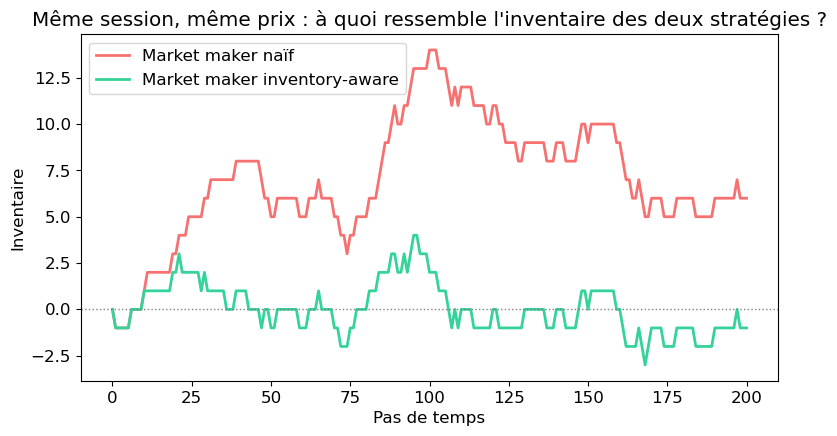

Inventaire max (naif) : 14   Inventaire max (inventory-aware) : 4


In [8]:
# Comparaison des trajectoires d'inventaire sur UNE session

s0, sigma, T, n_steps = 100.0, 2.0, 1.0, 200
gamma, kappa, A = 0.1, 1.5, 140

pnl_naive, q_naive = simuler_session(s0, sigma, T, n_steps, gamma, kappa, A, "naive", seed=1)
pnl_inv, q_inv = simuler_session(s0, sigma, T, n_steps, gamma, kappa, A, "inventory", seed=1)

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(q_naive, label="Market maker naïf", color="#f87171", linewidth=2)
ax.plot(q_inv, label="Market maker inventory-aware", color="#34d399", linewidth=2)
ax.axhline(0, color="grey", linestyle=":", linewidth=1)
ax.set_title("Même session, même prix : à quoi ressemble l'inventaire des deux stratégies ?")
ax.set_xlabel("Pas de temps")
ax.set_ylabel("Inventaire")
ax.legend()
plt.show()

print(f"Inventaire max (naif) : {np.max(np.abs(q_naive)):.0f}   "
      f"Inventaire max (inventory-aware) : {np.max(np.abs(q_inv)):.0f}")


## 8. Expériences

**Paramètre qu'on fait varier :** au lieu d'une seule session, on répète la simulation 3000 fois
avec des trajectoires de prix indépendantes, pour comparer les deux stratégies sur des statistiques
robustes plutôt que sur un seul essai.


In [9]:
# Une session ne prouve rien: on repete 3000 fois, avec des trajectoires
# de prix independantes a chaque fois, et on regarde les distributions.

n_sims = 3000
pnls_naive, pnls_inv, maxinv_naive, maxinv_inv = [], [], [], []

for sim in range(n_sims):
    pn, qn = simuler_session(s0, sigma, T, n_steps, gamma, kappa, A, "naive", seed=1000+sim)
    pi, qi = simuler_session(s0, sigma, T, n_steps, gamma, kappa, A, "inventory", seed=1000+sim)
    pnls_naive.append(pn); pnls_inv.append(pi)
    maxinv_naive.append(np.max(np.abs(qn))); maxinv_inv.append(np.max(np.abs(qi)))

pnls_naive, pnls_inv = np.array(pnls_naive), np.array(pnls_inv)
maxinv_naive, maxinv_inv = np.array(maxinv_naive), np.array(maxinv_inv)


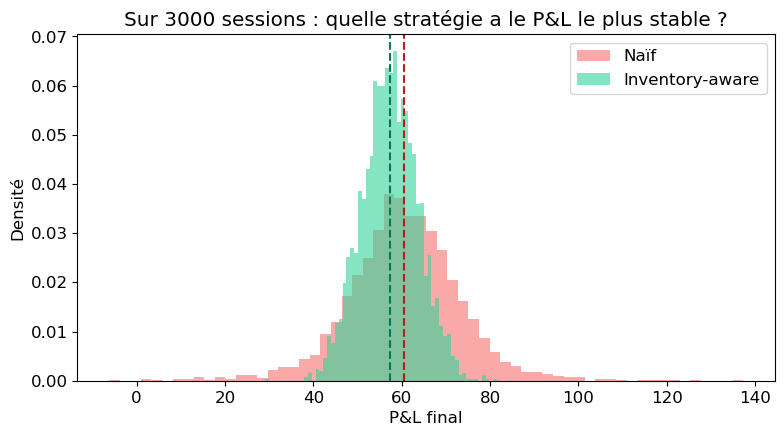

PnL moyen       -- naif: 60.56   inventory-aware: 57.27
PnL ecart-type  -- naif: 12.92   inventory-aware: 6.34
|inventaire| max moyen -- naif: 9.67   inventory-aware: 4.12


In [10]:
# Distributions de PnL, naif vs inventory-aware

fig, ax = plt.subplots(figsize=(9,4.5))
ax.hist(pnls_naive, bins=60, alpha=0.6, label="Naïf", color="#f87171", density=True)
ax.hist(pnls_inv, bins=60, alpha=0.6, label="Inventory-aware", color="#34d399", density=True)
ax.axvline(pnls_naive.mean(), color="#b91c1c", linestyle="--")
ax.axvline(pnls_inv.mean(), color="#047857", linestyle="--")
ax.set_title("Sur 3000 sessions : quelle stratégie a le P&L le plus stable ?")
ax.set_xlabel("P&L final")
ax.set_ylabel("Densité")
ax.legend()
plt.show()

print(f"PnL moyen       -- naif: {pnls_naive.mean():.2f}   inventory-aware: {pnls_inv.mean():.2f}")
print(f"PnL ecart-type  -- naif: {pnls_naive.std():.2f}   inventory-aware: {pnls_inv.std():.2f}")
print(f"|inventaire| max moyen -- naif: {maxinv_naive.mean():.2f}   inventory-aware: {maxinv_inv.mean():.2f}")


## 9. Résultats

- Les trois vérifications de la section 6 sont cohérentes avec la théorie : prix de réservation
  neutre à inventaire nul, décalage strictement monotone, convergence du spread vers une limite
  finie quand $\gamma \to 0$.
- Sur une session unique, l'inventory-aware contient déjà mieux l'inventaire que le naïf.
- Sur 3000 sessions indépendantes : le P&L moyen est très proche entre les deux stratégies
  (perte d'environ 5% en moyenne pour l'inventory-aware), mais son écart-type est environ **deux
  fois plus faible**, et l'inventaire maximum typique est également divisé par deux. Le market
  maker inventory-aware sacrifie un peu de gain moyen contre une réduction substantielle du risque.


## 10. Interprétation financière

**Pour un trader / market maker :** ce compromis — un peu moins de gain moyen contre beaucoup
moins de risque — est exactement le calcul qu'un desk fait en pratique. Un market maker qui ignore
son inventaire peut avoir de bonnes sessions, mais s'expose à des pertes bien plus importantes
que le spread qu'il collecte quand le marché part dans un sens.

**Pour un risk manager :** la réduction de moitié de l'inventaire maximum typique est directement
ce qui limite le capital à risque nécessaire pour couvrir l'activité de market making — un
inventaire moins volatil, c'est moins de VaR consommée par le desk.

**Pour un quant :** ce modèle est la base théorique derrière une grande partie du market making
algorithmique moderne — les extensions (Guéant, Cartea-Jaimungal, entre autres) ajoutent la
sélection adverse, l'asymétrie du carnet, ou des contraintes réglementaires sur l'inventaire.


## 11. Limites

1. **Marche aléatoire sans dérive** → un vrai marché a des tendances et des sauts que ce modèle
   ignore.
2. **Pas de sélection adverse** → en réalité, une partie du flux est "informée" (des traders qui
   savent quelque chose que le market maker ne sait pas) ; ce modèle traite tout le flux de la
   même façon, ce qui sous-estime le risque réel.
3. **Paramètres non calibrés** → $A$, $\kappa$ et $\gamma$ ont été choisis pour l'illustration,
   pas estimés sur un vrai carnet d'ordres.
4. **Article original non consulté directement** → la formule est vérifiée par recoupement de
   sources secondaires académiques, pas par lecture du papier de 2008 lui-même.


## 12. Conclusion

**Idée essentielle à retenir :**
> Le vrai risque d'un market maker n'est pas de perdre le spread — c'est de laisser son inventaire
> dériver sans le contrôler. Décaler ses prix en fonction de l'inventaire qu'on détient déjà,
> plutôt que de coter symétriquement, réduit fortement ce risque pour un coût faible sur le gain
> moyen.




## À vous de jouer

- Changez $\gamma$ (essayez 0,01 et 1,0) et relancez la section 8 : comment évolue le compromis
  gain moyen / risque ?
- Changez $\kappa$ : que se passe-t-il si les ordres arrivent beaucoup plus vite (A plus grand) ?
- Essayez de retirer la contrainte de temps (T-t constant plutôt que décroissant) : le modèle
  se comporte-t-il différemment en fin de session ?

Le code complet est disponible sur le repo GitHub de la chaîne : `02-market-maker-bid-ask/notebook.ipynb`.


---
## Sources

- Avellaneda, M. & Stoikov, S. (2008), *High-frequency trading in a limit order book*, Quantitative Finance, 8(3), 217-224
- J. Hull, *Options, Futures and Other Derivatives*, 8e éd.
- CFA Institute, *Fixed Income Analysis*
